<div style="display:none">
$$
\newcommand{\rvar}[1]{\mathrm{#1}}
\newcommand{\rvec}[1]{\mathbf{#1}}
\newcommand{\vec}[1]{\pmb{#1}}
\newcommand{\tens}[1]{\pmb{\mathsf{#1}}}
\newcommand{\tensel}[1]{\mathsf{#1}}
\newcommand{\st}[1]{\mathcal{#1}}
\newcommand{\diag}[1]{\mathrm{diag}(\vec{#1})}
$$
</div>

In [1]:
# some initialization stuff
%run ../init.py
%matplotlib inline
%load_ext tensorboard

plt.rcParams['image.cmap'] = 'Accent'
dev = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
device = torch.device(dev)
import nns.helpers as hp
from torch.utils.tensorboard import SummaryWriter

<IPython.core.display.Latex object>

# Multilayer networks

+ Perceptrons can only express linear decision surfaces
+ Multilayer networks learned by *Backpropagation* can express a variety of non-linear decision surfaces
+ However, multiple layers of linear Adaline neurons can still produce only linear surfaces
+ Perceptrons are hard to use as the discontinuous threshold make is undifferentiable $\Rightarrow$ unsuitable for gradient descent
+ We want new model that has the best properties of both: 
    - output is a non-linear function of its inputs, 
    - output is a differentiable function of its inputs
    - preferably with range $[0,1]$ as perceptron

## Simple multilayer perceptron

<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/03_DL/images/ann-mlp.jpg" width="60%"/>
</center>

## Computational graphs for multi-layer ANNs

- The same approach, as shown for a single neuron, can be applied to multi-layered networks
- Consider an 2-layer network in which ;
   - the hidden layer consists of a ReLU unit and the output layer of a sigmoid unit; 
   - both units have only one input 

<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/03_DL/images/dnn-forward.svg" width="70%"/>
</center>

- During the forward pass, a backward pass for the computation of gradients is recorded (shown in red)

<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/03_DL/images/dnn-backprop.svg" width="70%"/>
</center>

- Consider an example is presented to the network with the following parametrization:
  - the observation $\vec{x}=[1,3]$ with the target classification label $t=-1$ 
  - ReLU unit weights $w_0=-2, w_1=2$, and 
  - Sigmoid unit weights $w'_0=-1, w'_1=2$ 
  
<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/03_DL/images/dnn-backprop-ex.svg" width="70%"/>
</center>

In [2]:
X = torch.FloatTensor([1., 3.])
t = torch.FloatTensor([0])
w_1 = torch.tensor([-2., 2.], requires_grad=True)
w_2 = torch.tensor([-1., 2.], requires_grad=True)

# first neuron
s1 = X @ w_1
y1 = torch.relu(s1)

# adding bias
X_2 = torch.cat((torch.tensor([1]).reshape(1), y1.reshape(1)))

s2 =  X_2 @ w_2
y2 = torch.sigmoid(s2)

l = torch.pow(t - y2, 2)/2
l.backward()

In [3]:
display(Latex("$s_1 = {} \\to \hat y = {} \\to X_2 = [{},{}] \\to s^\\prime = {} \\to \\hat y^\\prime = {} \\to L(\\hat y^\\prime, t) = {}$".format(s1, y1, X_2[0], X_2[1], s2, y2, l[0])))

print('Neuron 1, weights: {}, gradient: {}'.format(w_1, w_1.grad))
print('Neuron 2, weights: {}, gradient: {}'.format(w_2, w_2.grad))

<IPython.core.display.Latex object>

Neuron 1, weights: tensor([-2.,  2.], requires_grad=True), gradient: tensor([0.0018, 0.0055])
Neuron 2, weights: tensor([-1.,  2.], requires_grad=True), gradient: tensor([0.0009, 0.0036])


## Expressive capabilities of ANNs

- Boolean functions:
    - Every Boolean function can be represented by network with single hidden layer
    - But might require a number of hidden units exponential in number of inputs
- Continuous functions:
    - Every bounded continuous function can be approximated with arbitrarily small error, by network with one hidden layer 
    - Any function can be approximated to arbitrary accuracy by a network with two hidden layers

In [4]:
class MLP(torch.nn.Module):
    def __init__(self, n=5, activation='relu'):
        super().__init__()
        md = [torch.nn.Linear(2,n)]
        if activation == 'tanh': md.append(torch.nn.Tanh())
        else: md.append(torch.nn.ReLU())
        md.extend([torch.nn.Linear(n,2), torch.nn.Softmax(dim=1)])      
        self._model = torch.nn.Sequential(*md)
        
    def forward(self, x):
        return self._model(x)

mlp = MLP()
print(mlp)

MLP(
  (_model): Sequential(
    (0): Linear(in_features=2, out_features=5, bias=True)
    (1): ReLU()
    (2): Linear(in_features=5, out_features=2, bias=True)
    (3): Softmax(dim=1)
  )
)


### Training and applying a model

In [5]:
def mlp_train(net, X, y):
    loss = torch.nn.CrossEntropyLoss()
    opt = torch.optim.SGD(net.parameters(), lr=0.1)
    current_loss = []
    
    net.train()
    for epoch in range(2000):
        # reset gradient
        opt.zero_grad()
        pred = net(X)
        l = loss(pred, y)
        l.backward()
        opt.step()

        current_loss.append(l.item())   
    return net, current_loss

def mlp_predict(X):
    if isinstance(X, np.ndarray):
        X = torch.from_numpy(X).float()
    mlp.eval()
    with torch.no_grad():
        return torch.argmax(mlp(X), dim=1)

In [6]:
@interact(fn=['and','or', 'xor'], activation=['tanh','relu'], neurons=(1,12,1))
def mlp(fn='xor', activation='relu', neurons=3):
    global mlp
    X = torch.tensor([[0., 0.], [1., 1.], [1., 0.], [0., 1.]])
    y = hp.switch_fn(fn)(X).long()
    mlp = MLP(neurons, activation)

    # train a multilayer perceptron with 1 hidden layer
    clf, loss = mlp_train(mlp, X, y)
    hp.plot_binary(mlp_predict, X, y) 
    plt.show()
    plt.plot(loss)
    plt.show();

interactive(children=(Dropdown(description='fn', index=2, options=('and', 'or', 'xor'), value='xor'), Dropdown…

In [7]:
model = MLP(10, 'tanh')
# small test
print(model(torch.randn((4, 2))))

tensor([[0.4613, 0.5387],
        [0.4159, 0.5841],
        [0.4215, 0.5785],
        [0.5295, 0.4705]], grad_fn=<SoftmaxBackward0>)


## Practical re-implementation of the model

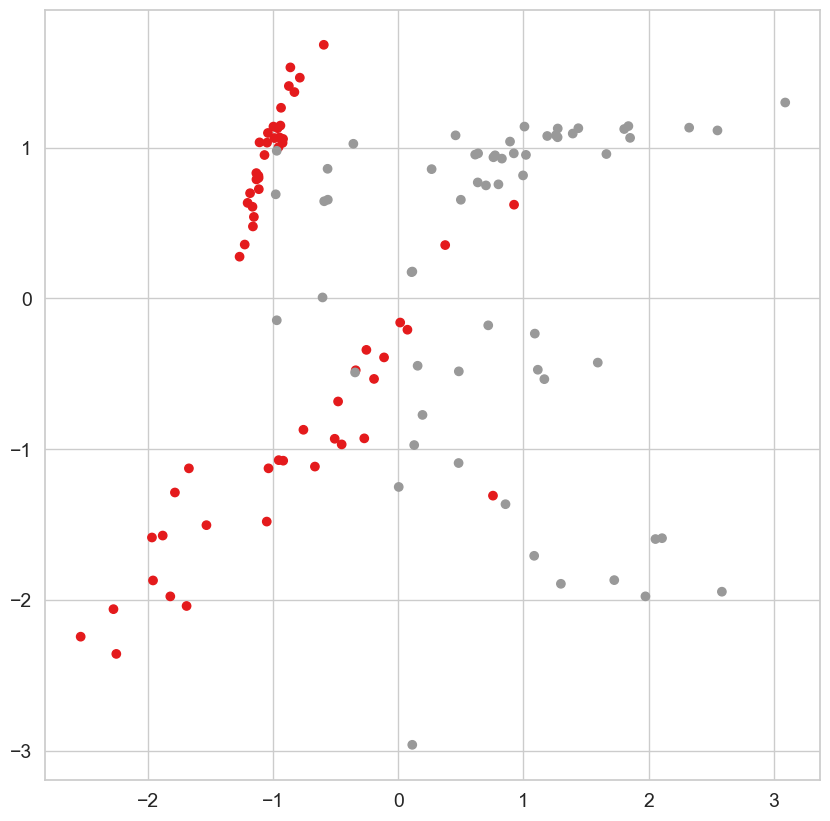

In [8]:
# define a function to load the data
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import make_classification

n = 120
split = 80
# generate data 
X, y = make_classification(n_samples = n, n_features=2, n_redundant=0, random_state=3)
plt.scatter(X[:,0],X[:,1], c=y, cmap='Set1');

### Create data loaders

In [9]:
# create datasets and loaders

ds = TensorDataset(torch.tensor(X, dtype=torch.float), torch.tensor(y, dtype=torch.long))
train_size = int(split*n/100)
ds_train, ds_val =  torch.utils.data.random_split(ds, [train_size,n-train_size])
dl_train = DataLoader(ds_train, batch_size=10)
dl_val = DataLoader(ds_val, batch_size=20)

### Define the training method

In [10]:
def train_tb():
    t_loss = 0
    t_acc = 0
    model.train()
    for X_b, y_b in dl_train:
        X_b, y_b = X_b.to(device), y_b.to(device)
        p = model(X_b)
        loss = loss_func(p, y_b)
        t_loss += loss
        t_acc += torch.sum(torch.argmax(p, dim=1) == y_b).item()

        opt.zero_grad()
        loss.backward()
        opt.step()
    
    return t_loss/len(dl_train), t_acc/len(dl_train.dataset)

### Validation method to control the training process

In [11]:
def validate_tb():    
    model.eval()
    with torch.no_grad():
        val_loss = 0
        val_acc = 0
        for x_v, y_v in dl_val:
            x_v, y_v = x_v.to(device), y_v.to(device)
            p = model(x_v)
            val_loss += loss_func(p, y_v).item()
            val_acc += torch.sum(torch.argmax(p, dim=1) == y_v).item()
                
    return val_loss/len(dl_val), val_acc/len(dl_val.dataset)

In [12]:
%%time

# Logging with TensorBoard
writer = SummaryWriter()

# training of the model
# n = 5, activation ='relu', 'tahn'
device='cpu'
model = MLP(10, 'relu').to(device)
loss_func = torch.nn.CrossEntropyLoss().to(device)
opt = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

# store the model graph with some training examples from the dataloader
writer.add_graph(model, next(iter(dl_train))[0])

for i in range(1000):
    t_loss, t_acc = train_tb()
    writer.add_scalar("Loss/train", t_loss , i)
    writer.add_scalar("Acc/train", t_acc , i)
    
    # validation of the model 
    val_loss, val_acc = validate_tb()
    writer.add_scalar("Loss/val", val_loss, i)
    writer.add_scalar("Acc/val", val_acc, i)

print('epoch: {}, loss: {}, val_loss: {}'.format(i, t_loss, val_loss)) 
writer.close()

epoch: 999, loss: 0.44574737548828125, val_loss: 0.40402883291244507
CPU times: user 2.29 s, sys: 1.55 s, total: 3.84 s
Wall time: 2.79 s


In [13]:
# %tensorboard --logdir runs

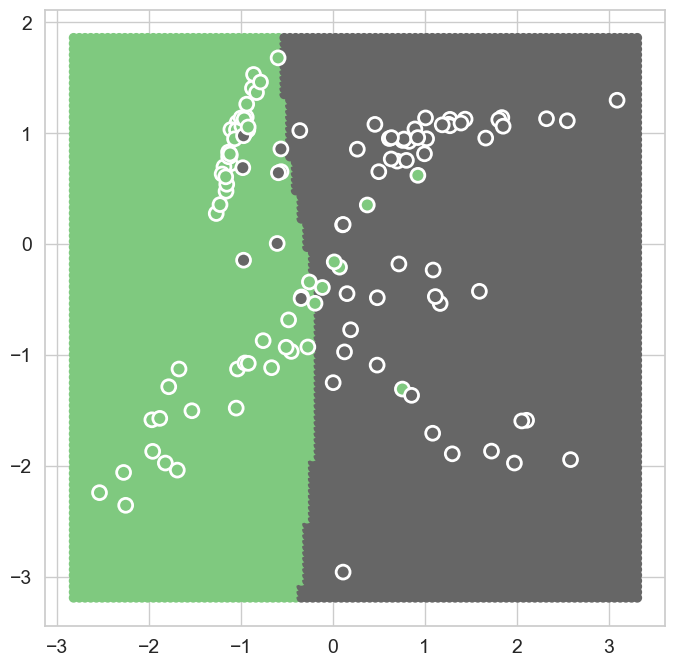

In [14]:
md = model.cpu()
torch_predict = lambda x: torch.max(md(torch.tensor(x, dtype=torch.float)), dim=1)[1]
hp.plot_binary(torch_predict, X, y)

# Multilayer ANNs: inductive bias / prior knowledge

## Machine learning is an *ill-posed* problem

- Infinitely many ways to infer an entire distribution which generated observed samples $\vec{X}$
    - Hard to select ANN architecture that fits exactly the true data generator    
- Architecture defines variance - set of functions an ANN can theoretically learn
- High variance quite often results in low bias of the model
    - Slow convergence
    - High volumes of data
    - Overfitting and weak generalizations from training examples

## Loss functions - a small guide

- The loss function is usually defined as $L = \frac{1}{N} \sum_{i=1}^N L_i$, 
where $N$ is a number of observations and $L_i$ are losses measured for $i$-th observation
- Selection of a loss function depends on the problem
- Classification binary or multi-class - assign one class from a set of classes (see [Section 03](../01_Introduction/03_information.ipynb) and [Section 05](../01_Introduction/05_functions.ipynb) for details):
  - Output layer: softmax (hierarchical softmax for large number of classes that are organized in a tree)
  - Loss: binary/categorial cross-entropy (default), hinge (SVM - binary classification) or categorial hinge, Kullback-Leibler divergence
-  Multi-label classification (assign a subset of a set of classes):
   - Output layer: sigmoid (marginal probabilities for classes)
   - Loss: sigmoid cross-entropy (default), binary cross-entropy (measured for each class separtely, e.g., by setting a threshold on values output by each sigmoid unit)
- Regression:
  - Output layer: linear activation
  - Loss: mean squared error (default), logarithmic MSE (large values), mean absolute value (many outliers)

## Regularization in DL

- *Regularization* is an important method to to find a good balance between variance and bias
    - provides preference for the choice of a distribution - inductive bias or prior knowledge
    - reduce the risk of overfitting and improve generalization
- These strategies achieve their goal by adding various restrictions/constraints
    - on the model, e.g., constraints on the parameter values
    - on the optimization function, e.g., penalties for too large/small parameter values
    - encoding of a specific prior knowledge, e.g., reflecting the imbalance of the data
    - expressing preferences for models, e.g., simpler models may have better generalization

## Parameter norms

- Regularization is a well-known approach, which is widely used in ML
    - In *lasso* and *ridge* regression, the objective function is extended with $L_1$ and $L_2$ norm of the weights, respectively
        - Lasso: $\min_\vec{w} f(\vec{X} \mid \vec{w}) = \lVert \vec{X}\vec{w}-\vec{y}\rVert_2^2 + \lambda(\lVert\vec{w}\rVert_1-c)$
        - Ridge: $\min_\vec{w} f(\vec{X} \mid \vec{w}) =\lVert \vec{X}\vec{w}-\vec{y}\rVert_2^2 + \lambda(\lVert\vec{w}\rVert_2^2-c)$
        - where $\lambda$ is a regularization parameter and $c$ is the upper bound for the norm
- Similarly in DL the objective function $J$ can be modified by adding a term $\Omega(\vec{w})$, where $\vec{w}$ comprises only weights and no biases


$$\tilde{J}(\vec{X}, \vec{y} \mid \vec{w}) = J(\vec{X}, \vec{y} \mid \vec{w}) + \lambda \Omega(\vec{w})$$

## $L_2$ regularization

- Similarly to the ridge regression, the $L_2$ regularization results in a weight decay
$$\Omega(\vec{w}) = \frac{1}{2}\|\vec{w}\|_2^2$$
- As a result, the objective function
$$\tilde{J}(\vec{X}, \vec{y} \mid \vec{w}) = J(\vec{X}, \vec{y} \mid \vec{w}) + \frac{\lambda}{2} \vec{w}^\top\vec{w}$$
- Then, the gradient  
$$\nabla_\vec{w}\tilde{J}(\vec{X}, \vec{y} \mid \vec{w}) = \nabla_\vec{w} J(\vec{X}, \vec{y} \mid \vec{w}) + \lambda \vec{w}$$
- and the update rule
$$\vec{w} \gets \vec{w} - \eta(\nabla_\vec{w} J(\vec{X}, \vec{y} \mid \vec{w}) + \lambda \vec{w})$$
- which can we rewritten as
$$\vec{w} \gets (1 - \eta\lambda)\vec{w} - \eta\nabla_\vec{w} J(\vec{X}, \vec{y} \mid \vec{w}) $$

- Consequently, the weights are decayed by $(1 - \eta\lambda)$ before each update!
- If considering quadratic optimization problem, it can be shown that the weights are rescaled by Hessian eigenvalues
    - preserve directions associated with large eigenvalues contributing to the reduction of the objective function
    - decay other directions

## $L_1$ regularization

$$\Omega(\vec{w}) = \|\vec{w}\|_1$$
- As a result, the gradient is increased/reduces by $\lambda$ depending on the sign of a weight $w_i$ 
$$\nabla_\vec{w}\tilde{J}(\vec{X}, \vec{y} \mid \vec{w}) = \nabla_\vec{w} J(\vec{X}, \vec{y} \mid \vec{w}) + \lambda\, \text{sign}(\vec{w})$$
- and the update rule
$$\vec{w} \gets \vec{w} - \eta(\nabla_\vec{w} J(\vec{X}, \vec{y} \mid \vec{w}) + \lambda\,\text{sign}(\vec{w}))$$
- This regularization modifies the gradient with a constant factor $\lambda$ with a sign equal to $\text{sign}(\vec{w})$
- Therefore, $L_1$ regularization results in a more sparse solution, i.e., some parameters have an optimal value $0$
    - $\Rightarrow$ $L_1$ is quite often used as a feature selection

## Early stopping

- Early stopping is an unobtrusive form of regularization
    - Can be used alone or in combination with other methods
    - Required validation set
- Every time validation error improves, we store a copy of the network
- Stop training when the validation error has not decreased by more than some small amount for some number of epochs
    - Training can be continued from this point or restarted 
- Reduction of costs: a well-tuned early stopping can save researchers time and money

## Dataset augmentation & Noise robustness

<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/03_DL/images/noise.png" width="60%"/>
</center>

<div class="cite">Goodfellow, Ian J., Jonathon Shlens, and Christian Szegedy. "Explaining and harnessing adversarial examples." arXiv preprint arXiv:1412.6572 (2014)</div>

## Dataset augmentation & Noise robustness

- More examples $\Rightarrow$ better generalization
    - Amount of data is limited in practice
    - Add fake but reasonable data to the dataset
- Some data, like images or sounds, are pretty easy to augment
    - Rotations, cropping, mirroring, pitch shifting, background noise
    - Adversarial examples
- Small amount of noise can be directly injected into inputs
- Noise injection can be applied to the hidden units (Bayesian networks)
    - Model weights are uncertain and 
    - Represent via a probability distribution
    - Select $\vec{w}$ for which small perturbations of $\vec{w}$ have a relatively small influence on the output

## Semi-supervised learning

- Uses unlabeled examples from $P(\rvar{x})$ and labeled examples from $P(\rvar{x}, \rvar{y})$ to predict $\rvar{y}$ from $\rvar{x}$, i.e., estimate $P(\rvar{y} \mid \rvar{x})$
- A network should learn a *representation* $\vec{h}=f(\vec{x})$ such that examples from the same class have similar representations
    - E.g., for any observation $\vec{x}_i$, the Euclidean distance between $\vec{h}_i = f(\vec{x}_i)$ and $\vec{h}_j = f(\vec{x}_j)$ for any $\vec{x}_j$ from the same class must be smaller than between $\vec{h}_i$ and $\vec{h}_k = f(\vec{x}_k)$, for any $\vec{x}_k$ from a different class
- Unsupervised part using examples from $P(\rvar{x})$ is used to provide information on how to group examples in the representation space

## Ensemble methods

- Model averaging is a powerful method to improve the generalization
- Train several models and let them vote for the result
    - If errors of members are uncorrelated, the ensemble performs better than any of its members
    - Use *weak learners* - very simple networks that are not prone to overfitting
- Ensembles can be constructed in various ways

### Bagging

- Bagging decreases variance and reduces the risk of overfitting
- Trains one and the same model on $k$ datasets obtained by sampling with replacement (duplicates are allowed)
- All models are trained *independently* and in parallel

### Boosting 

- Boosting decreases bias, not variance
- Trains the one and the same model focusing it on observations that cannot be explained by previously trained ones - *dependent models*
    - constructs $k$ different datasets by sampling with replacement 
    - sampling is done according to the performance of previously trained models - the worse are the results, the higher is the probability for a sample to be selected